In [1]:
import sys
sys.path.append('..')
import xarray as xr
import pandas as pd
from scipy import constants
import numpy as np
import matplotlib.pyplot as plt
import calendar
import glob

### GC posterior

In [2]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
all_xch4_posterior = []
for year in years:
    # set directory
    if year == 2019:
        dirname = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/posterior_run/OutputDir/'
    else:
        dirname = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/posterior_run/OutputDir/'

    # Open StateMet collection (monthly)
    met_ds = xr.open_mfdataset(dirname + f'GEOSChem.StateMet.{year}*')
    mol_dry_air = (met_ds["Met_AIRDEN"] * met_ds["Met_AIRVOL"])*1e3/28.96 # mol

    # Open BoundaryConditions collection (1st day of each month)
    # this is the same as SpeciesConc collection but with the first hour (t=0) outputted. 3-hour timesteps in each file
    BC_ds = xr.open_mfdataset(dirname+f"GEOSChem.BoundaryConditions.{year}*01_0000z.nc4")
    mol_ch4 = BC_ds['SpeciesBC_CH4'] * mol_dry_air

    # mean XCH4 excluding south of -60 latitude
    xch4 = 1e9 * (
        mol_ch4.sel(lat=mol_ch4["lat"] > -60).sum(dim="lev") / 
        mol_dry_air.sel(lat=mol_dry_air["lat"] > -60).sum(dim="lev")
    ).mean(dim=["lat", "lon"])

    xch4 = xch4.to_numpy()

    all_xch4_posterior.extend(xch4)

### GC prior

In [5]:
years = [2019, 2020, 2021, 2022]
all_xch4_prior = []
for year in years:
    # set directory
    if year == 2019:
        dirname = f'/n/netscratch/jacob_lab/Lab/mhe/Global_{year}_annual_edgarv7/jacobian_runs/Global_{year}_annual_edgarv7_0000/OutputDir/'
    else:
        dirname = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/jacobian_runs/Global_{year}_annual_0000/OutputDir/'

    # Open StateMet collection (monthly)
    met_ds = xr.open_mfdataset(dirname + f'GEOSChem.StateMet.{year}*')
    mol_dry_air = (met_ds["Met_AIRDEN"] * met_ds["Met_AIRVOL"])*1e3/28.96 # mol

    # Open BoundaryConditions collection (1st day of each month)
    # this is the same as SpeciesConc collection but with the first hour (t=0) outputted. 3-hour timesteps in each file
    BC_ds = xr.open_mfdataset(dirname+f"GEOSChem.BoundaryConditions.{year}*01_0000z.nc4")
    mol_ch4 = BC_ds['SpeciesBC_CH4'] * mol_dry_air

    # mean XCH4 excluding south of -60 latitude
    xch4 = 1e9 * (
        mol_ch4.sel(lat=mol_ch4["lat"] > -60).sum(dim="lev") / 
        mol_dry_air.sel(lat=mol_dry_air["lat"] > -60).sum(dim="lev")
    ).mean(dim=["lat", "lon"])

    xch4 = xch4.to_numpy()

    all_xch4_prior.extend(xch4)

OSError: no files to open

### GC orig prior

In [3]:
years = [2019, 2020, 2021, 2022]
all_xch4_prior_orig = []
for year in years:
    # set directory
    if year == 2019:
        dirname = f'/n/netscratch/jacob_lab/Lab/mhe/Global_{year}_annual_edgarv7/jacobian_runs/Global_{year}_annual_edgarv7_0000/OutputDir/'
    else:
        dirname = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/jacobian_runs/Global_{year}_annual_0000/OutputDir_origprior/'

    # Open StateMet collection (monthly)
    met_ds = xr.open_mfdataset(dirname + f'GEOSChem.StateMet.{year}*')
    mol_dry_air = (met_ds["Met_AIRDEN"] * met_ds["Met_AIRVOL"])*1e3/28.96 # mol

    # Open BoundaryConditions collection (1st day of each month)
    # this is the same as SpeciesConc collection but with the first hour (t=0) outputted. 3-hour timesteps in each file
    BC_ds = xr.open_mfdataset(dirname+f"GEOSChem.BoundaryConditions.{year}*01_0000z.nc4")
    mol_ch4 = BC_ds['SpeciesBC_CH4'] * mol_dry_air

    # mean XCH4 excluding south of -60 latitude
    xch4 = 1e9 * (
        mol_ch4.sel(lat=mol_ch4["lat"] > -60).sum(dim="lev") / 
        mol_dry_air.sel(lat=mol_dry_air["lat"] > -60).sum(dim="lev")
    ).mean(dim=["lat", "lon"])

    xch4 = xch4.to_numpy()

    all_xch4_prior_orig.extend(xch4)

### Prepare df's for plotting

In [3]:
all_xch4 = np.array(all_xch4_posterior)
datetimes = pd.date_range(start=f"{years[0]}-01-01", end=f"{years[-1]}-12-01", freq="MS")

df_posterior = pd.DataFrame({"xch4": all_xch4}, index=datetimes)
df_posterior.index.name = "Month"

In [4]:
ch4_noaa = pd.read_csv("../noaa_ch4_mm_gl_2019-2024.csv", usecols=["date", "average"], index_col="date", parse_dates=True)
ch4_noaa.rename(columns={"average": "ch4"}, inplace=True)

ch4_noaa
# datetimes = pd.date_range(start=f"{years[0]}-01-01", end=f"{years[-1]}-12-01", freq="MS")

# df_obspack = pd.DataFrame({"xch4": all_xch4}, index=datetimes)
# df_obspack.index.name = "Year"

,ch4
date,
2019-01-01,1864.98
2019-02-01,1865.03
2019-03-01,1866.33
2019-04-01,1865.32
2019-05-01,1861.98
...,...
2024-08-01,1925.96
2024-09-01,1935.71
2024-10-01,1941.70


In [5]:
all_xch4 = np.array(all_xch4_prior_orig)
datetimes = pd.date_range(start=f"{years[0]}-01-01", end=f"{years[-1]}-12-01", freq="MS")

df_prior = pd.DataFrame({"xch4": all_xch4}, index=datetimes)
df_prior.index.name = "Month"

NameError: name 'all_xch4_prior_orig' is not defined

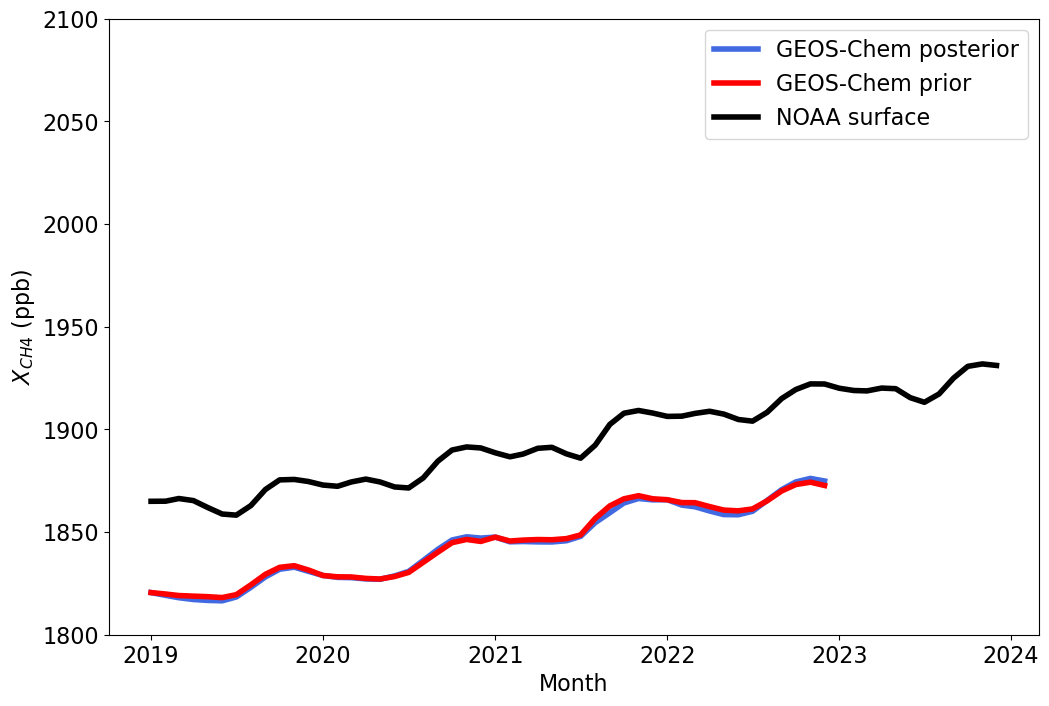

In [19]:
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
plt.plot(df_posterior,linewidth=4,c='royalblue',label='GEOS-Chem posterior')
plt.plot(df_prior,linewidth=4,c='red',label='GEOS-Chem prior')
plt.plot(ch4_noaa,linewidth=4,c='black',label='NOAA surface')
plt.ylim(1800,2100)
plt.xlabel('Month')
plt.ylabel('$X_{CH4}$ (ppb)')
plt.legend()
plt.show()

In [5]:
df_year_posterior = df_posterior.resample('YS').mean()
posterior_2019 = df_year_posterior.iloc[0,0]

df_year_posterior['percent_change'] = ((df_year_posterior['xch4'] - posterior_2019) / posterior_2019) * 100
df_year_posterior

,xch4,percent_change
Month,,
2019-01-01,1822.949585,0.000000
2020-01-01,1833.594238,0.583925
2021-01-01,1850.327637,1.501855
2022-01-01,1864.904663,2.301494
2023-01-01,1874.193726,2.811056
2024-01-01,1880.735840,3.169931


In [9]:
df_year_prior = df_prior.resample('YS').mean()
prior_2019 = df_year_prior.iloc[0,0]

df_year_prior['percent_change'] = ((df_year_prior['xch4'] - prior_2019) / prior_2019) * 100
df_year_prior

NameError: name 'df_prior' is not defined

In [6]:
ch4_noaa_year = ch4_noaa.resample('YS').mean()
ch4_noaa_2019 = ch4_noaa_year.iloc[0,0]

ch4_noaa_year['percent_change'] = ((ch4_noaa_year['ch4'] - ch4_noaa_2019) / ch4_noaa_2019) * 100

### Get TROPOMI methane data

In [7]:
def load_tropomi_data(year):
    obs_file = f"/n/home12/mhe/lfs/Global_{year}_annual/data_converted_extracted_fullyear/obs_tropomi.npz"
    time_file = f"/n/home12/mhe/lfs/Global_{year}_annual/data_converted_extracted_fullyear/time.npz"
    
    obs = np.load(obs_file)['y']
    time = np.load(time_file)['time']
    time = pd.to_datetime(time, format='%Y%m%d')
    
    return pd.DataFrame({
        'time': time,
        'obs': obs,
        'year': year
    })

In [8]:
obs_2019 = np.load("/n/home12/mhe/lfs/Global_2019_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2019 = np.load("/n/home12/mhe/lfs/Global_2019_annual/data_converted_extracted_fullyear/time.npz")

obs_2020 = np.load("/n/home12/mhe/lfs/Global_2020_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2020 = np.load("/n/home12/mhe/lfs/Global_2020_annual/data_converted_extracted_fullyear/time.npz")

obs_2021 = np.load("/n/home12/mhe/lfs/Global_2021_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2021 = np.load("/n/home12/mhe/lfs/Global_2021_annual/data_converted_extracted_fullyear/time.npz")

obs_2022 = np.load("/n/home12/mhe/lfs/Global_2022_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2022 = np.load("/n/home12/mhe/lfs/Global_2022_annual/data_converted_extracted_fullyear/time.npz")

obs_2023 = np.load("/n/home12/mhe/lfs/Global_2023_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2023 = np.load("/n/home12/mhe/lfs/Global_2023_annual/data_converted_extracted_fullyear/time.npz")

obs_2024 = np.load("/n/home12/mhe/lfs/Global_2024_annual/data_converted_extracted_fullyear/obs_tropomi.npz")
time_2024 = np.load("/n/home12/mhe/lfs/Global_2024_annual/data_converted_extracted_fullyear/time.npz")

obs_2019_mean = obs_2019['y'].mean()
obs_2020_mean = obs_2020['y'].mean()
obs_2021_mean = obs_2021['y'].mean()
obs_2022_mean = obs_2022['y'].mean()
obs_2023_mean = obs_2023['y'].mean()
obs_2024_mean = obs_2024['y'].mean()

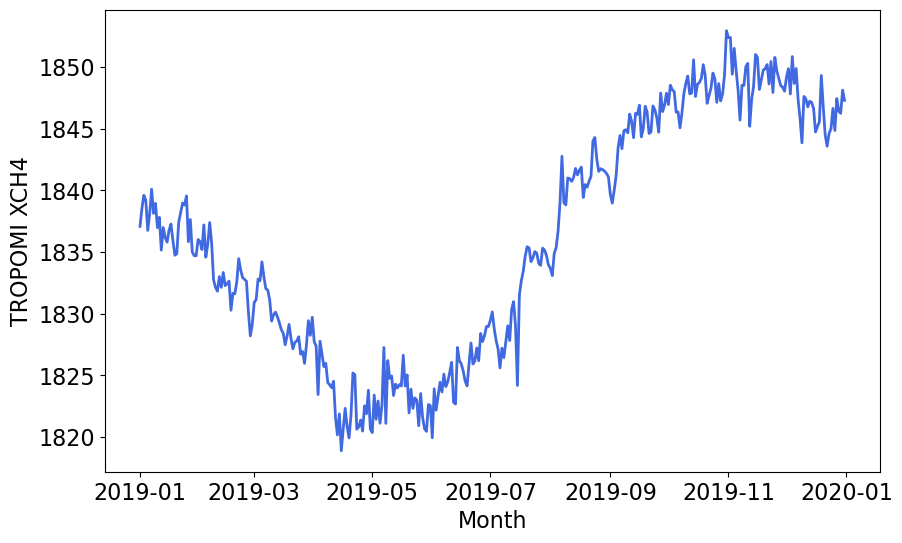

In [4]:
time_2019 = pd.to_datetime(time_2019['time'], format='%Y%m%d')

df_2019 = pd.DataFrame({
    'XCH4': obs_2019['y']
}, index=time_2019)

obs_2019_daily_mean = df_2019.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2019_daily_mean, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.show()

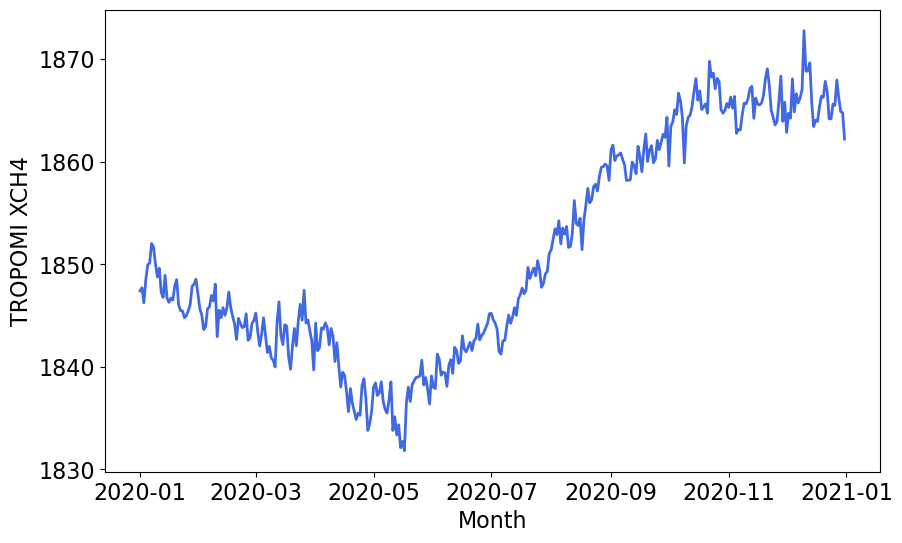

In [5]:
time_2020 = pd.to_datetime(time_2020['time'], format='%Y%m%d')

df_2020 = pd.DataFrame({
    'XCH4': obs_2020['y']
}, index=time_2020)

obs_2020_daily_mean = df_2020.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2020_daily_mean, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.show()

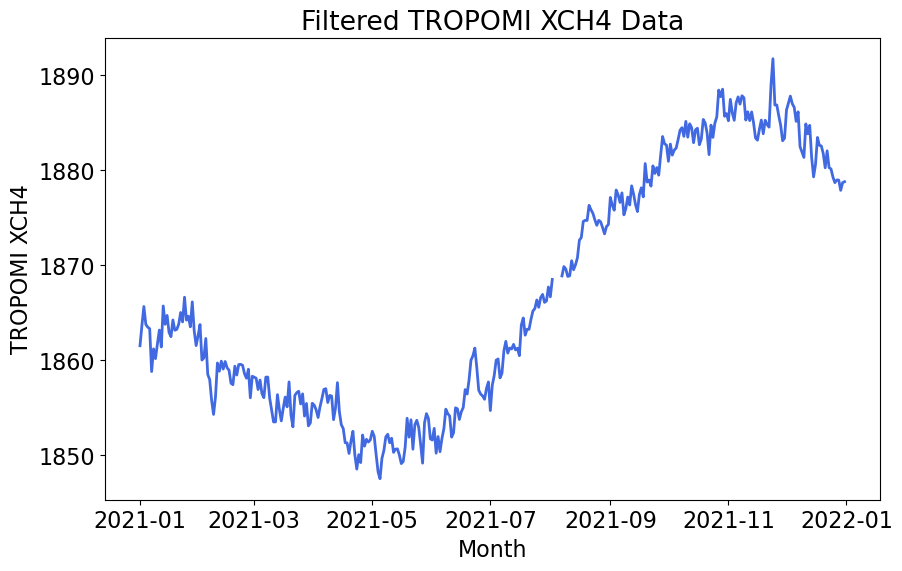

In [46]:
time_2021 = pd.to_datetime(time_2021['time'], format='%Y%m%d')

df_2021 = pd.DataFrame({
    'XCH4': obs_2021['y']
}, index=time_2021)

# Filter and remove outliers in this data gap range
outlier_date_range = df_2021.loc['2021-08-03':'2021-08-06']
condition = (outlier_date_range['XCH4'] <= 1950) & (outlier_date_range['XCH4'] >= 1800)
df_2021_cleaned = df_2021.drop(outlier_date_range[~condition].index)

# daily mean
obs_2021_daily_mean = df_2021_cleaned.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2021_daily_mean, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.title('Filtered TROPOMI XCH4 Data')
plt.show()

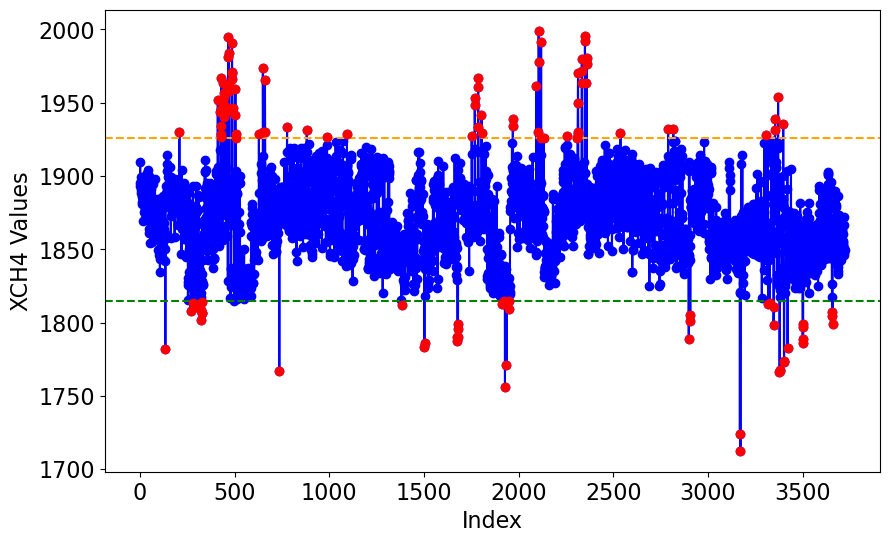

In [47]:
test = df_2021.loc['2021-08-03':'2021-08-06']['XCH4'].to_numpy()
# Calculate mean and standard deviation
mean_test = np.mean(test)
std_test = np.std(test)

# Define the 2-sigma range
lower_bound = mean_test - 2 * std_test
upper_bound = mean_test + 2 * std_test

# Identify outliers
outliers = test[(test < lower_bound) | (test > upper_bound)]
outlier_indices = np.where((test < lower_bound) | (test > upper_bound))[0]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(test, label='Data', marker='o', linestyle='-', color='blue')
plt.scatter(outlier_indices, outliers, color='red', label='Outliers', zorder=5)

# Highlight the bounds
plt.axhline(lower_bound, color='green', linestyle='--', label='Lower 2σ bound')
plt.axhline(upper_bound, color='orange', linestyle='--', label='Upper 2σ bound')

# Add labels and legend
plt.xlabel('Index')
plt.ylabel('XCH4 Values')

# Show the plot
plt.show()

## Filter 2022

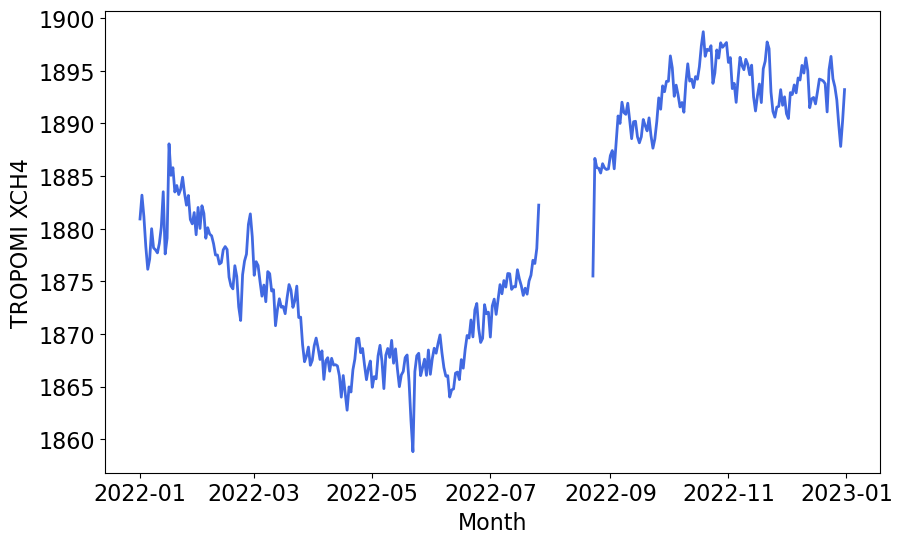

In [36]:
# pre-filtering
# time_2022 = pd.to_datetime(time_2022['time'], format='%Y%m%d')

# df_2022 = pd.DataFrame({
#     'XCH4': obs_2022['y']
# }, index=time_2022)

# obs_2022_daily_mean = df_2022.resample('D').mean()

# fig = plt.figure(figsize=(10, 6))
# plt.rcParams.update({"font.size": 16})
# plt.plot(obs_2022_daily_mean, linewidth=2, color='royalblue')
# plt.xlabel('Month')
# plt.ylabel('TROPOMI XCH4')
# plt.show()

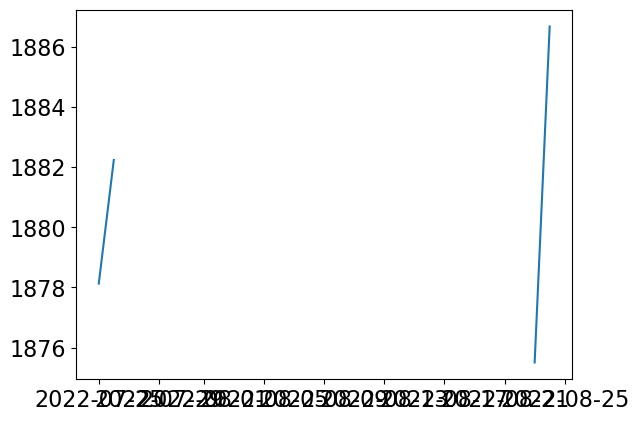

In [43]:
plt.plot(obs_2022_daily_mean.loc['2022-07-25':'2022-08-24'])

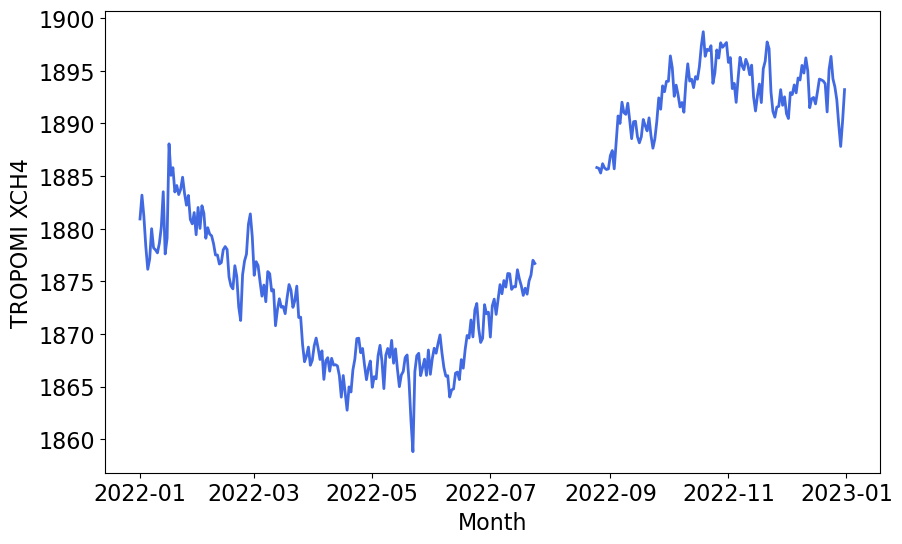

In [3]:
# post filtering, 1/11/2025
time_2022 = pd.to_datetime(time_2022['time'], format='%Y%m%d')

df_2022 = pd.DataFrame({
    'XCH4': obs_2022['y']
}, index=time_2022)

obs_2022_daily_mean = df_2022.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2022_daily_mean, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.show()

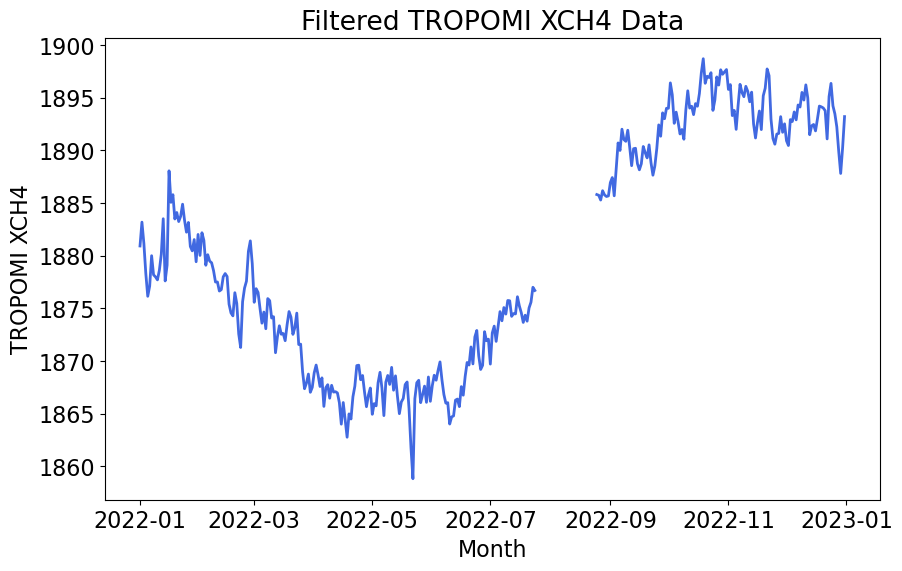

In [6]:
time_2022 = pd.to_datetime(time_2022['time'], format='%Y%m%d')

df_2022 = pd.DataFrame({
    'XCH4': obs_2022['y']
}, index=time_2022)

# Filter and remove outliers in this data gap range
outlier_date_range = df_2022.loc['2022-07-25':'2022-08-24']
condition = (outlier_date_range['XCH4'] <= 2000) & (outlier_date_range['XCH4'] >= 1800)
df_2022_cleaned_old = df_2022.drop(outlier_date_range[~condition].index)

# daily mean
obs_2022_daily_mean_old = df_2022_cleaned_old.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2022_daily_mean_old, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.title('Filtered TROPOMI XCH4 Data')
plt.show()

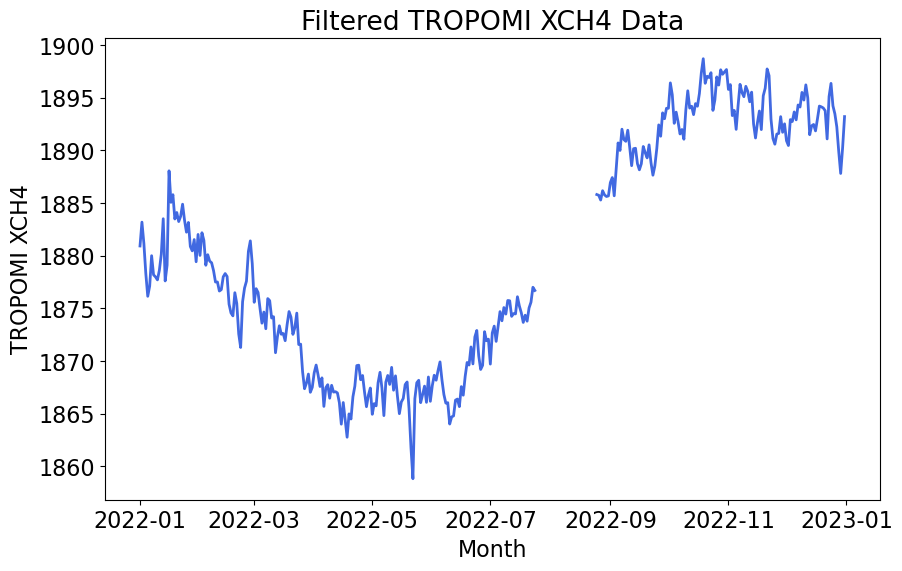

In [7]:
# time_2022 = pd.to_datetime(time_2022['time'], format='%Y%m%d')

# df_2022 = pd.DataFrame({
#     'XCH4': obs_2022['y']
# }, index=time_2022)

df_2022_cleaned = df_2022.drop(df_2022.loc['2022-07-25':'2022-08-24'].index)

# daily mean
obs_2022_daily_mean = df_2022_cleaned.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2022_daily_mean, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.title('Filtered TROPOMI XCH4 Data')
plt.show()

In [8]:
print(len(df_2022_cleaned_old))
print(len(df_2022_cleaned))

597663
597451


## Filter 2023

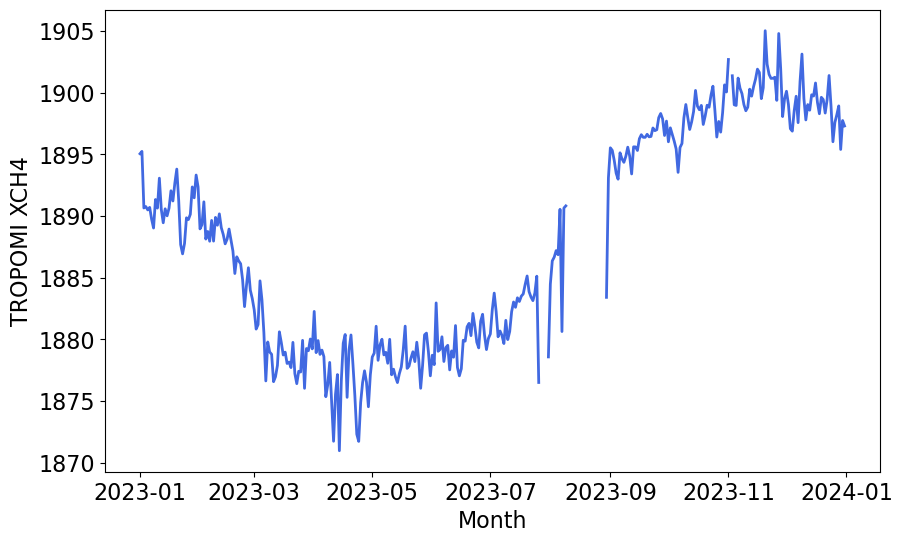

In [9]:
time_2023 = pd.to_datetime(time_2023['time'], format='%Y%m%d')

df_2023 = pd.DataFrame({
    'XCH4': obs_2023['y']
}, index=time_2023)

obs_2023_daily_mean = df_2023.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2023_daily_mean, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.show()

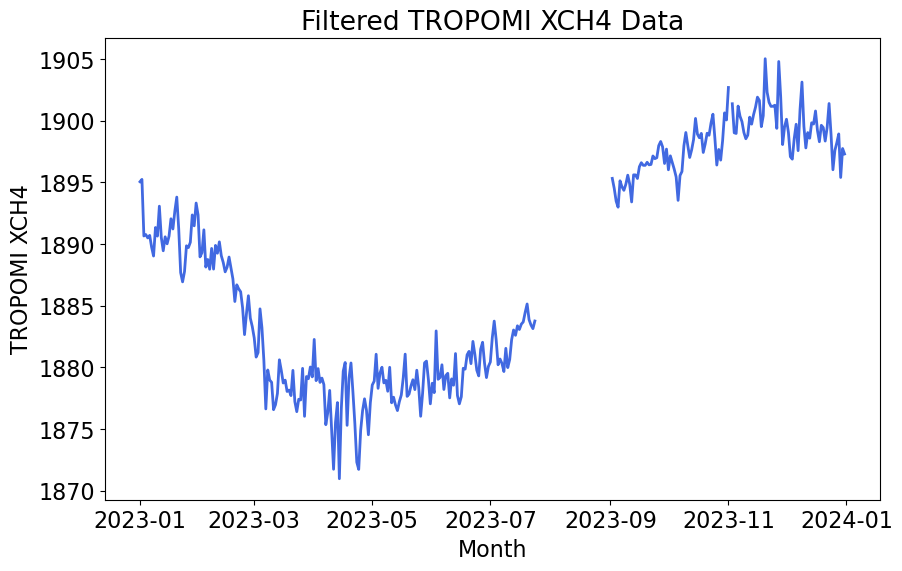

In [ ]:
# Remove outliers (not entire days)

# time_2023 = pd.to_datetime(time_2023['time'], format='%Y%m%d')

# df_2023 = pd.DataFrame({
#     'XCH4': obs_2023['y']
# }, index=time_2023)

# Filter and remove outliers in this data gap range
outlier_date_range = df_2023.loc['2023-07-25':'2023-09-01']
condition = (outlier_date_range['XCH4'] <= 2000) & (outlier_date_range['XCH4'] >= 1800)
df_2023_cleaned_old = df_2023.drop(outlier_date_range[~condition].index)

# daily mean
obs_2023_daily_mean_old = df_2023_cleaned_old.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2023_daily_mean_old, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.title('Filtered TROPOMI XCH4 Data')
plt.show()

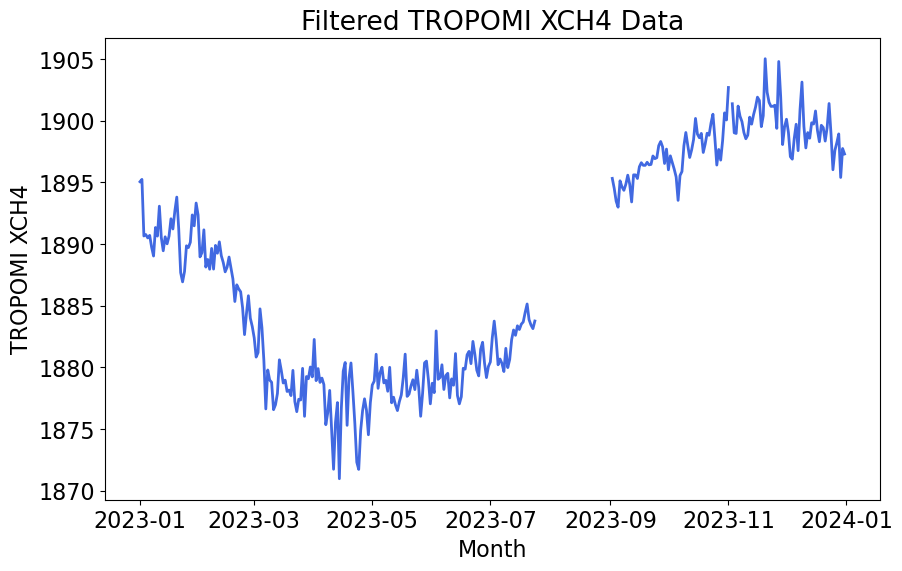

In [21]:
# Remove entire days

# time_2023 = pd.to_datetime(time_2023['time'], format='%Y%m%d')

# df_2023 = pd.DataFrame({
#     'XCH4': obs_2023['y']
# }, index=time_2023)

# Filter and remove outliers in this data gap range
df_2023_cleaned = df_2023.drop(df_2023.loc['2023-07-26':'2023-09-01'].index)

# daily mean
obs_2023_daily_mean = df_2023_cleaned.resample('D').mean()

fig = plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 16})
plt.plot(obs_2023_daily_mean_old, linewidth=2, color='royalblue')
plt.xlabel('Month')
plt.ylabel('TROPOMI XCH4')
plt.title('Filtered TROPOMI XCH4 Data')
plt.show()

In [22]:
print(len(df_2023_cleaned_old))
print(len(df_2023_cleaned))

586659
586797


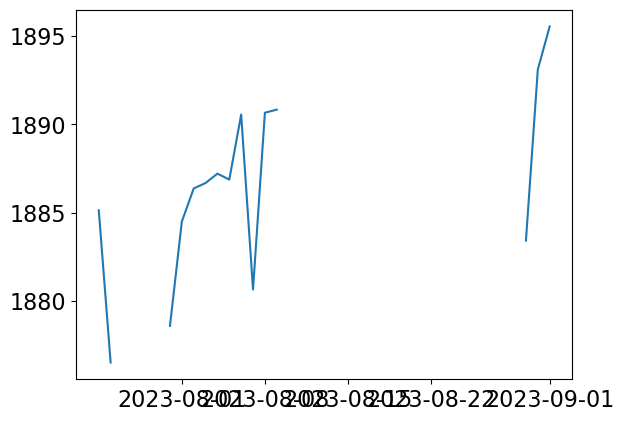

In [25]:
plt.plot(obs_2023_daily_mean.loc['2023-07-25':'2023-09-01'])

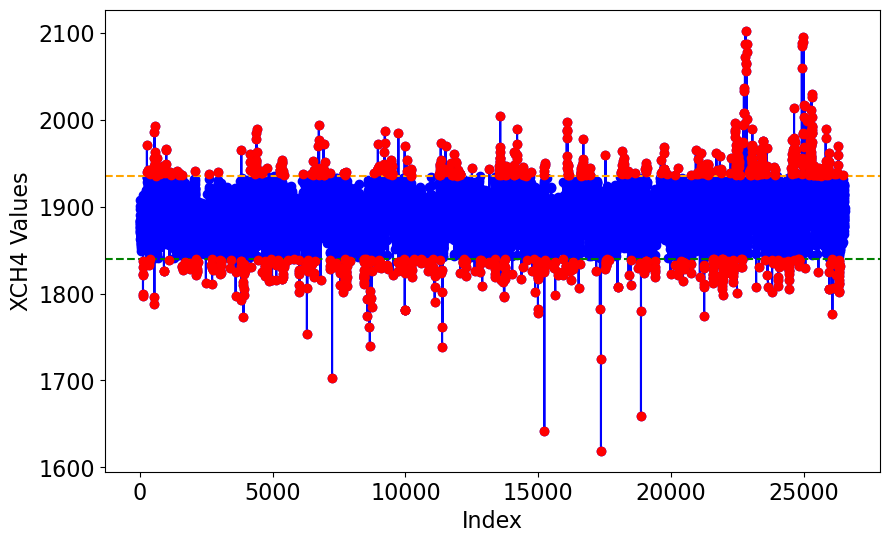

In [26]:
test = df_2023.loc['2023-07-25':'2023-09-01']['XCH4'].to_numpy()
# Calculate mean and standard deviation
mean_test = np.mean(test)
std_test = np.std(test)

# Define the 2-sigma range
lower_bound = mean_test - 2 * std_test
upper_bound = mean_test + 2 * std_test

# Identify outliers
outliers = test[(test < lower_bound) | (test > upper_bound)]
outlier_indices = np.where((test < lower_bound) | (test > upper_bound))[0]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(test, label='Data', marker='o', linestyle='-', color='blue')
plt.scatter(outlier_indices, outliers, color='red', label='Outliers', zorder=5)

# Highlight the bounds
plt.axhline(lower_bound, color='green', linestyle='--', label='Lower 2σ bound')
plt.axhline(upper_bound, color='orange', linestyle='--', label='Upper 2σ bound')

# Add labels and legend
plt.xlabel('Index')
plt.ylabel('XCH4 Values')

# Show the plot
plt.show()

In [9]:
obs = [obs_2019_mean, obs_2020_mean, obs_2021_mean, obs_2022_mean, obs_2023_mean, obs_2024_mean]
df_tropomi = pd.DataFrame({
    'Year': pd.to_datetime([f'{year}-01-01' for year in years]),  # Create a datetime index
    'xch4': obs
})
df_tropomi.set_index('Year', inplace=True)
tropomi_2019 = df_tropomi.iloc[0,0]

df_tropomi['percent_change'] = ((df_tropomi['xch4'] - tropomi_2019) / tropomi_2019) * 100

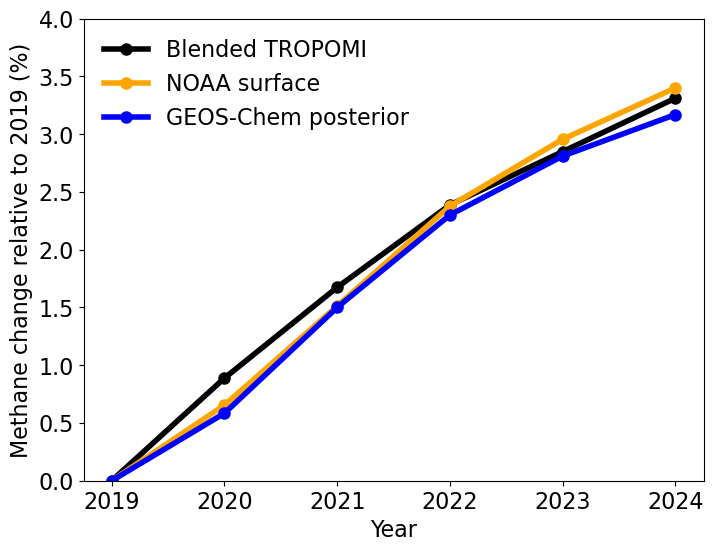

In [15]:
fig = plt.figure(figsize=(8, 6))
plt.rcParams.update({"font.size": 16})
# plt.plot(df_year_prior['percent_change'],linewidth=4,c='blue',linestyle="--",label='GEOS-Chem prior')
plt.plot(df_tropomi['percent_change'],linewidth=4,color='black',marker='o',markersize='8',label='Blended TROPOMI')
plt.plot(ch4_noaa_year['percent_change'],linewidth=4,c='orange',marker='o',markersize='8',label='NOAA surface')
plt.plot(df_year_posterior['percent_change'],linewidth=4,c='blue',marker='o',markersize='8',label='GEOS-Chem posterior')
plt.xticks(df_year_posterior.index, df_year_posterior.index.year)
plt.ylim(0,4)
plt.xlabel('Year')
plt.ylabel('Methane change relative to 2019 (%)')
plt.legend(frameon=False, loc='upper left')
plt.show()

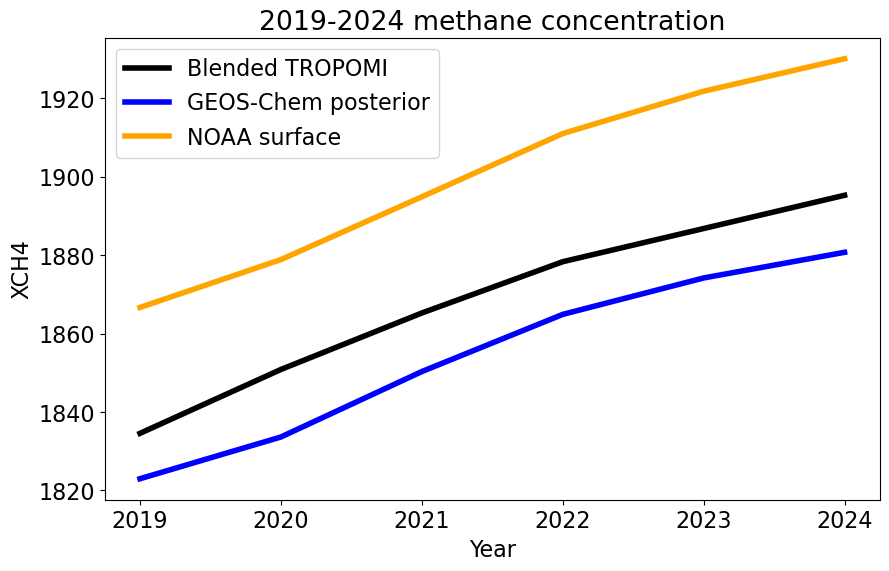

In [11]:
fig = plt.figure(figsize=(10, 6))
plt.plot(df_tropomi['xch4'],linewidth=4,color='black',label='Blended TROPOMI')
# plt.plot(df_year_prior['xch4'],linewidth=4,c='blue',linestyle="--",label='GEOS-Chem prior')
plt.plot(df_year_posterior['xch4'],linewidth=4,c='blue',label='GEOS-Chem posterior')
plt.plot(ch4_noaa_year['ch4'],linewidth=4,c='orange',label='NOAA surface')
plt.xticks(df_year_posterior.index, df_year_posterior.index.year)
plt.xlabel('Year')
plt.ylabel('XCH4')
plt.title('2019-2024 methane concentration')
plt.legend()
plt.show()